# Lab 8: Assessing Sea Ice Trends

In this notebook, you'll learn to assess trends in time series in passive microwave sea ice data available from the National Snow and Ice Data Center.

This notebook has three components:
1. Generate a monthly timeseries of sea ice area from 1979 to present
2. Analyze trends of sea ice area during the September sea ice minimum
3. Compute the trend in sea ice in a given area

**Import the modules for this notebook**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import os
import datetime as dt

### Define a data path and download the data
In this box below, define a `file_folder` where you will download the sea ice data. Then, use the **Downloading Data from NSIDC** data to obtain the level 3 sea ice data for the Northern Hemisphere, available here: https://noaadata.apps.nsidc.org/NOAA/G02202_V4/north/monthly/ 

In [4]:
# define a path to your raster files folder 
file_folder = '/Users/mike/Documents/Teaching/Courses/MS 274/Labs/Lab 8/Raster Data'

## Part 1: Generating a timeseries of sea ice data
Before reading in all of the data in a loop, it's helpful to open up a single file and see what's inside. Use the Panoply program to get a list of the variables and determine the name of the sea ice variable will be useful for generating a timeseries of sea ice area.

### Explore a file
After determining which variable will be used for the sea ice area calculation, read in the grid into an array

In [5]:
# make a file path to one of the nc files
file_path = file_folder+'/seaice_conc_monthly_nh_197901_n07_v04r00.nc'

# open the file and read in the sea ice variable to a 2D numpy grid
ds = nc4.Dataset(file_path)
seaice_grid = np.array(ds.variables['nsidc_nt_seaice_conc_monthly'])
ds.close()

# print the minimum and maximum of the grid
print('minimum:',np.min(seaice_grid))
print('maximum:',np.max(seaice_grid))

minimum: 0.0
maximum: 254.0


Sea ice concentration is supposed to be in the range 0-1. What's going on here? To get a sense of this data, it helps to have a visual.

### Make a histogram

A histogram will give us a sense of where our data lies. 

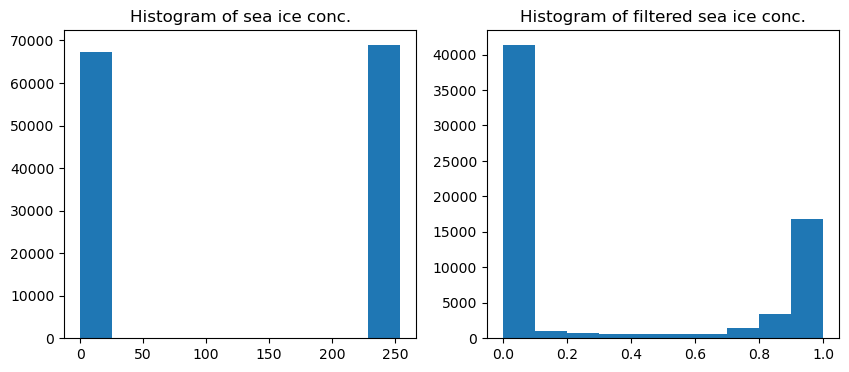

In [6]:
# ravel the seaice data - the histogram plotting function needs a 1D array
seaice_grid = seaice_grid.ravel()

# make a figure object
fig = plt.figure(figsize=(10,4))

# plot a histogram of the data and add a title
plt.subplot(1,2,1)
plt.hist(seaice_grid)
plt.title('Histogram of sea ice conc.')

# create a filtered version of the data
seaice_values_filtered = seaice_grid[seaice_grid<2]

# plot a histogram of the filtered data and add a title
plt.subplot(1,2,2)
plt.hist(seaice_values_filtered)
plt.title('Histogram of filtered sea ice conc.')

# show the figure
plt.show()

### Compute the total sea ice area for the test file

In [7]:
# Find the number of points with a sea ice fraction greater than 15%
seaice_points = np.sum(seaice_values_filtered>0.15)

# Convert to area (in km^2) assuming a grid resolution of 25 km by 25 km
seaice_area = seaice_points*25*25

# print the sea ice area
print('seaice area:',seaice_area,'km^2')

seaice area: 15850625 km^2


### Make a timeseries from the sea ice area

In [8]:
# make a sorted file list of all the sea ice nc files
file_list = []
for file_name in os.listdir(file_folder):
    if file_name[-3:]=='.nc':
        file_list.append(file_name)

# sort the file list
file_list.sort()

# make empty lists called date_list and seaice_values
# to store data from all of the files
date_list = []
seaice_values = []

# loop through all of the files in the file list
for file_name in file_list:
    
    # make a date string for the file
    date_str = file_name.split('_')[4][:4]+'-'+file_name.split('_')[4][4:6]+'-15'
    
    # open the file to get the seaice grid
    file_path = file_folder+'/'+file_name
    ds = nc4.Dataset(file_path)
    seaice_grid = np.array(ds.variables['nsidc_nt_seaice_conc_monthly'])
    ds.close()

    # compute the total area of seaice in this grid
    seaice_grid = seaice_grid.ravel()
    seaice_values_filtered = seaice_grid[seaice_grid<2]
    seaice_area = np.sum(seaice_values_filtered*25*25)

    # if the sea ice area value is valid (>0), add the date to the date list
    # and the value to the value list 
    if seaice_area>0:
        date_list.append(date_str)
        seaice_values.append(seaice_area)

# make a date_array from the date_list
date_array = np.array(date_list, dtype = 'datetime64')
    

## Plot the seaice timeseries

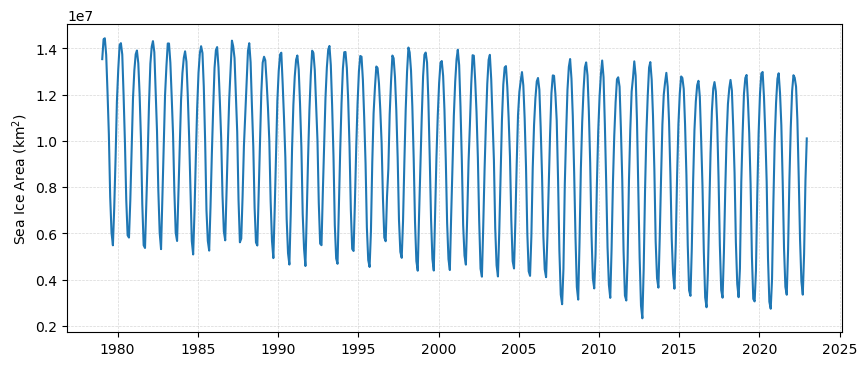

In [9]:
# make a figure object with a width of 10 and a height of 4
fig = plt.figure(figsize=(10,4))

# make a plot of the sea ice values vs the date array
plt.plot(date_array, seaice_values)

# label the y axis
plt.ylabel('Sea Ice Area (km$^2$)')

# make a grid
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)

# show the figure
plt.show()

# Part 2: Analyze trends in sea ice in September
The extent of sea ice at the September seaice minimum is the an important metric of overall sea ice health as well as for commerce.

## Filtering the seaice trend by month

In [10]:
sept_date_list = []
sept_seaice_values = []
for i in range(len(date_array)):
    date = date_array[i].astype(dt.datetime)
    if date.month == 9:
        sept_date_list.append(date)
        sept_seaice_values.append(seaice_values[i])

## Plot the filtered timeseries

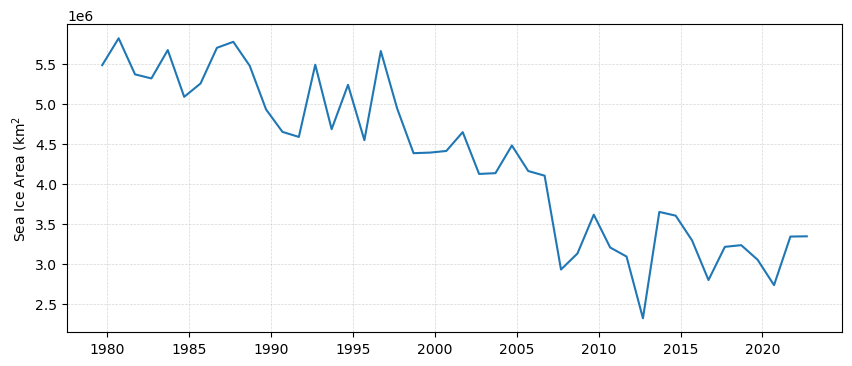

In [11]:
# make a figure object with a width of 10 and a height of 4
fig = plt.figure(figsize=(10,4))

# plot the september values
plt.plot(sept_date_list, sept_seaice_values)

# label the y axis
plt.ylabel('Sea Ice Area (km$^2$')

# make a grid
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)

# show the figure
plt.show()

## Define a function for decimal years


In [12]:
# define a function to turn a date, given by year, month, and day, into a decimal year
def YMD_to_DecYr(year,month,day):
    
    # define a date object using the datetime module
    date = dt.datetime(year,month,day)

    # define the start in ordinal units (days since ...)
    start = dt.date(date.year, 1, 1).toordinal()

    # compute the year_length in ordinal units (365 or 366)
    year_length = dt.date(date.year+1, 1, 1).toordinal() - start

    # compute the fraction based on the date
    decimal_fraction = float(date.toordinal() - start) / year_length

    # compute the decimal year
    dec_yr = year+decimal_fraction
    return(dec_yr)

Test the decimal year function:

In [13]:
# test your function below:
print(YMD_to_DecYr(2000,1,1))   # January 1, 2000
print(YMD_to_DecYr(2000,6,8))   # June 8, 2000
print(YMD_to_DecYr(2000,12,7))  # December 7, 2000

2000.0
2000.4344262295083
2000.931693989071


## Make a decimal year array for the September values

In [14]:
# make an empty list for the decimal years
sept_decyr_values = []
for date in sept_date_list:
    dec_yr = YMD_to_DecYr(date.year,date.month,date.day)
    sept_decyr_values.append(dec_yr)

## Compute the best fit line

In [15]:
# use numpy's polyfit function to compute the best fit line
p = np.polyfit(sept_decyr_values, sept_seaice_values, 1)

# the slope value is the first value
slope = p[0]

# the intercept is the second value
intercept = p[1]

# compute the values of the best fit line 
# for the september decyr values
best_fit = slope*np.array(sept_decyr_values)+intercept

## Create the plot with the line of best fit

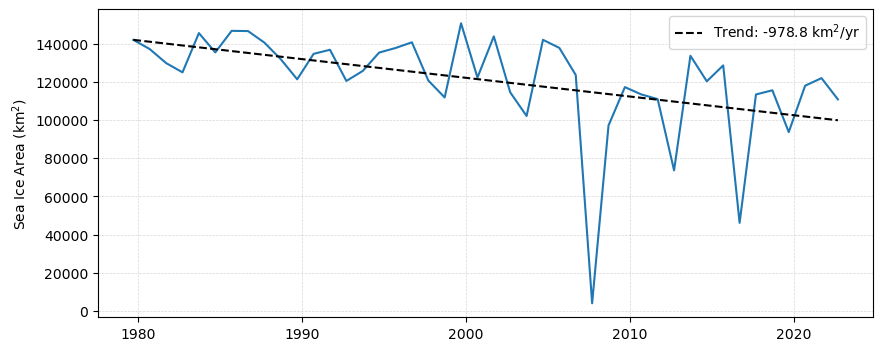

In [29]:
# make a figure object with a width of 10 and a height of 4
fig = plt.figure(figsize=(10,4))

# plot the september values
plt.plot(sept_decyr_values, sept_seaice_values)

# plot the line of best fit
# add a label which includes the trend
plt.plot(sept_decyr_values, best_fit, 'k--', label='Trend: '+'{:.1f}'.format(p[0])+' km$^2$/yr')

# label the y axis
plt.ylabel('Sea Ice Area (km$^2$)')

# make a grid
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)

# make a legend
plt.legend()

# show the figure
plt.show()

# Part 3: Computing regional sea ice trends

The region north of Greenland is the location of the thickest sea ice in the Arctic.

Open QGIS and add the global coastline. Then, change your projection to the projection of the sea ice data. Then, find the bounds of your box in the projected coordinates.

In [17]:
# define the bounds of the box north of the Fram Strait near Greenland and Svalbard
min_x = -729230
min_y = 444406
max_x = -376689
max_y = 875493

In [18]:
# make a file path to one of the nc files
file_path = file_folder+'/seaice_conc_monthly_nh_197901_n07_v04r00.nc'

# open the file and read in the sea ice variable to a 2D numpy grid
ds = nc4.Dataset(file_path)
x_grid = np.array(ds.variables['xgrid'])
y_grid = np.array(ds.variables['ygrid'])
seaice_grid = np.array(ds.variables['nsidc_nt_seaice_conc_monthly'])
ds.close()

In [19]:
# find the indices of the box bounds in the x and y grids
min_x_index = np.argmin(np.abs(x_grid-min_x))
max_y_index = np.argmin(np.abs(y_grid-min_y))
max_x_index = np.argmin(np.abs(x_grid-max_x))
min_y_index = np.argmin(np.abs(y_grid-max_y))

# print the indices to be sure these are ordered correctly
print('x indices:',min_x_index,max_x_index)
print('y indices:',min_y_index,max_y_index)

x indices: 124 138
y indices: 198 216


In [20]:
# print the shape of the seaice grid 
print(np.shape(seaice_grid))

# take only the "first timestep" of the seaice grid
seaice_grid = seaice_grid[0, :, :]

# subset the grid and find the area of sea ice in the subset
seaice_grid_subset = seaice_grid[min_y_index:max_y_index, min_x_index:max_x_index]

# print the shape of the seaice grid
print(np.shape(seaice_grid_subset))

(1, 448, 304)
(18, 14)


## Revisit the sea ice timeseries loop to create a timeseries in the defined box

In [21]:
# make a sorted file list of all the sea ice nc files
file_list = []
for file_name in os.listdir(file_folder):
    if file_name[-3:]=='.nc':
        file_list.append(file_name)

# sort the file list
file_list.sort()

# make empty lists called date_list and seaice_values
# to store data from all of the files
date_list = []
seaice_values = []

# loop through all of the files in the file list
for file_name in file_list:
    
    # make a date string for the file
    date_str = file_name.split('_')[4][:4]+'-'+file_name.split('_')[4][4:6]+'-15'
    
    # open the file to get the seaice grid
    file_path = file_folder+'/'+file_name
    ds = nc4.Dataset(file_path)
    seaice_grid = np.array(ds.variables['nsidc_nt_seaice_conc_monthly'])
    ds.close()

    # take only the "first timestep" of the seaice grid
    seaice_grid = seaice_grid[0, :, :]
    
    # subset the grid and find the area of sea ice in the subset
    seaice_grid_subset = seaice_grid[min_y_index:max_y_index, min_x_index:max_x_index]

    # compute the total area of seaice in this grid
    seaice_grid = seaice_grid_subset.ravel()
    seaice_values_filtered = seaice_grid[seaice_grid<2]
    seaice_area = np.sum(seaice_values_filtered*25*25)

    # if the sea ice area value is valid (>0), add the date to the date list
    # and the value to the value list 
    if seaice_area>0:
        date_list.append(date_str)
        seaice_values.append(seaice_area)

# make a date_array from the date_list
date_array = np.array(date_list, dtype = 'datetime64')

## Plot the timeseries in the box

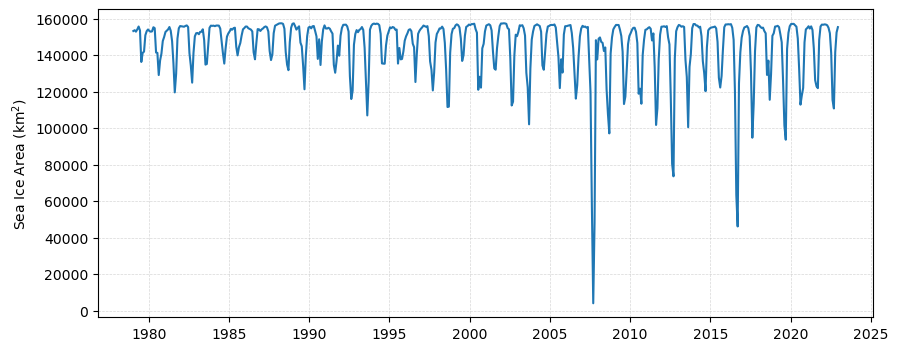

In [22]:
# make a figure object with a width of 10 and a height of 4
fig = plt.figure(figsize=(10,4))

# make a plot of the sea ice values vs the date array
plt.plot(date_array, seaice_values)

# label the y axis
plt.ylabel('Sea Ice Area (km$^2$)')

# make a grid
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)

# show the figure
plt.show()

### Filter the timeseries to only include values in September

In [23]:
sept_date_list = []
sept_seaice_values = []
for i in range(len(date_array)):
    date = date_array[i].astype(dt.datetime)
    if date.month == 9:
        sept_date_list.append(date)
        sept_seaice_values.append(seaice_values[i])

In [24]:
# make an empty list for the decimal years
sept_decyr_values = []
for date in sept_date_list:
    dec_yr = YMD_to_DecYr(date.year,date.month,date.day)
    sept_decyr_values.append(dec_yr)

In [25]:
# use numpy's polyfit function to compute the best fit line
p = np.polyfit(sept_decyr_values, sept_seaice_values, 1)

# the slope value is the first value
slope = p[0]

# the intercept is the second value
intercept = p[1]

# compute the values of the best fit line 
# for the september decyr values
best_fit = slope*np.array(sept_decyr_values)+intercept

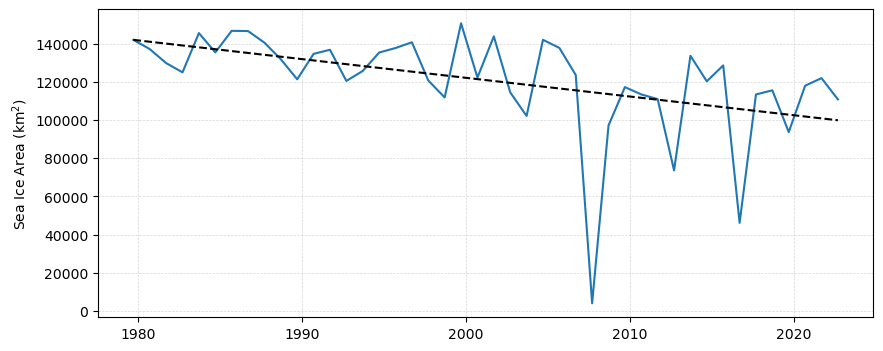

In [26]:
# make a figure object with a width of 10 and a height of 4
fig = plt.figure(figsize=(10,4))

# plot the september values
plt.plot(sept_decyr_values, sept_seaice_values)

# plot the line of best fit
plt.plot(sept_decyr_values, best_fit, 'k--')

# label the y axis
plt.ylabel('Sea Ice Area (km$^2$)')

# make a grid
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)

# show the figure
plt.show()